In [3]:
from IPython.display import display, Image  # This line lets you display images. We'll use that in a bit.

# This line lets you use python to download data from the web.
import requests

### Exercise 1

Write a function that takes in the width and height and prints an image

In [4]:
r = requests.get('http://www.placecats.com/2000/300')

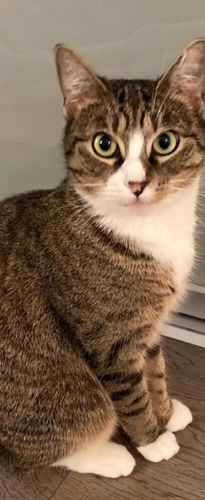

In [5]:
def my_cats(width, height):
    url = f'http://www.placecats.com/{width}/{height}'
    r = requests.get(url)
    display(Image(r.content))

my_cats(205,500)

### Exercise 2

Can you write a loop to show several images?


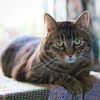

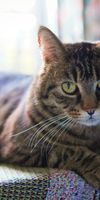

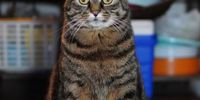

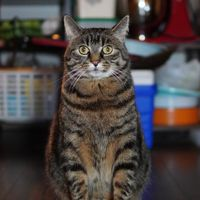

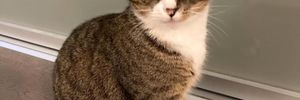

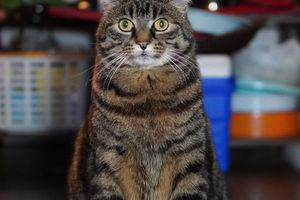

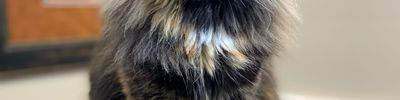

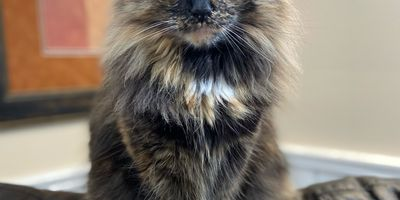

In [6]:
for width in range(100,500,100):
    for height in [100,200]:
        my_cats(width=width, height=height)

### Exercise 3

Use the .json() function to get the response converted to a dictionary or list

In [7]:
r = requests.get("http://time.now/developer/api/timezone")
print(r.json())

['W-SU', 'WET', 'Zulu', 'posixrules', 'CET', 'CST6CDT', 'Cuba', 'EET', 'EST', 'EST5EDT', 'Egypt', 'Eire', 'Factory', 'GB', 'GB-Eire', 'GMT', 'GMT+0', 'GMT-0', 'GMT0', 'Greenwich', 'HST', 'Hongkong', 'Iceland', 'Iran', 'Israel', 'Jamaica', 'Japan', 'Kwajalein', 'Libya', 'MET', 'MST', 'MST7MDT', 'NZ', 'NZ-CHAT', 'Navajo', 'PRC', 'PST8PDT', 'Poland', 'Portugal', 'ROC', 'ROK', 'Singapore', 'Turkey', 'UCT', 'UTC', 'Universal', 'Africa/Sao_Tome', 'Africa/Timbuktu', 'Africa/Tripoli', 'Africa/Tunis', 'Africa/Windhoek', 'Africa/Abidjan', 'Africa/Accra', 'Africa/Addis_Ababa', 'Africa/Algiers', 'Africa/Asmara', 'Africa/Asmera', 'Africa/Bamako', 'Africa/Bangui', 'Africa/Banjul', 'Africa/Bissau', 'Africa/Blantyre', 'Africa/Brazzaville', 'Africa/Bujumbura', 'Africa/Cairo', 'Africa/Casablanca', 'Africa/Ceuta', 'Africa/Conakry', 'Africa/Dakar', 'Africa/Dar_es_Salaam', 'Africa/Djibouti', 'Africa/Douala', 'Africa/El_Aaiun', 'Africa/Freetown', 'Africa/Gaborone', 'Africa/Harare', 'Africa/Johannesburg', 'A

### Exercise 4

Get the time for your time zone

In [8]:
r = requests.get('http://time.now/developer/api/timezone/America/Indiana/Indianapolis')

In [9]:
r.json()['datetime'][11:19]

'14:15:09'

In [10]:
r.json()

{'abbreviation': 'EST',
 'client_ip': '128.210.107.131',
 'datetime': '2026-03-05T14:15:09.801070-05:00',
 'day_of_week': 4,
 'day_of_year': 64,
 'dst': False,
 'dst_from': None,
 'dst_offset': 0,
 'dst_until': None,
 'raw_offset': -18000,
 'timezone': 'America/Indiana/Indianapolis',
 'unixtime': 1772738109,
 'utc_datetime': '2026-03-05T19:15:09.801136Z',
 'utc_offset': '-05:00',
 'week_number': 10}

In [11]:
from datetime import datetime

dt = r.json()['unixtime']
dt = datetime.fromtimestamp(dt)

In [12]:
dt

datetime.datetime(2026, 3, 5, 14, 15, 9)

### Exercise 5

Get the time for your IP address

## Exercise 6

Review the documentation (and Google) to see if you can figure out how to get a list of all of the users who have ever edited the most recently edited Wikipedia page.

In [13]:
endpt = 'https://en.wikipedia.org/w/api.php'

session = requests.Session()
session.headers.update({'User-Agent': 'IPDSTeachingDemo/0.1 (jdfoote@purdue.edu)'})


In [14]:
def get_most_recent_changed_page(session):

    parameters = {
    "format": "json",
    "rcprop": "title|ids",
    "list": "recentchanges",
    "action": "query",
    "rclimit": "1",
    'rcnamespace': '0'
}
    r = session.get(url=endpt, params=parameters)
    data = r.json()
    recent_changes = data['query']['recentchanges']
    #print(recent_changes)
    page_title = recent_changes[0]['title']
    return page_title

#for rc in RECENTCHANGES:
#    print(str(rc['title']))
#    r = session.get(endpt)
#for x in get_most_recent_changed_page(session):
#    print(x)

In [15]:
get_most_recent_changed_page(session)

'Angonyx williami'

In [27]:
def get_all_editors(page, editors = [], continue_val = None):
    parameters = {
    "action": "query",
    "prop": "revisions",
    "titles": page,
    "rvprop": "timestamp|user|comment",
    "rvslots": "main",
    "formatversion": "2",
    "format": "json",
    'rvlimit': "50"
    }
    if continue_val:
        print(continue_val)
        parameters.update(continue_val)
    
    r = session.get(url=endpt, params=parameters)
    data = r.json()
    print(data)
    revisions = data['query']['pages'][0]['revisions']
    for r in revisions:
        curr_editor = r['user']
        editors.append(curr_editor)
    if 'continue' in data:
        return get_all_editors(page, editors=editors, continue_val=data['continue'])
    else:
        return editors

last_page = get_most_recent_changed_page(session)
editors = get_all_editors(last_page)

print(last_page)
print(len(editors))

{'continue': {'rvcontinue': '20210221110108|1008066086', 'continue': '||'}, 'query': {'pages': [{'pageid': 127593, 'ns': 0, 'title': 'Tuckahoe (village), New York', 'revisions': [{'user': 'Magnolia677', 'timestamp': '2026-03-05T19:23:26Z', 'comment': '/* Geography */ Clean up/copyedit'}, {'user': 'Magnolia677', 'timestamp': '2026-03-05T19:23:04Z', 'comment': 'trivial in lead'}, {'user': 'Magnolia677', 'timestamp': '2026-03-05T19:22:31Z', 'comment': 'Undid revision [[Special:Diff/1341885784|1341885784]] by [[Special:Contributions/~2026-12766-64|~2026-12766-64]] ([[User talk:~2026-12766-64|talk]]) Removing unsourced content'}, {'user': '~2026-12766-64', 'temp': True, 'timestamp': '2026-03-05T19:05:26Z', 'comment': 'I corrected the misinformation as tuckahoe is from the Powhatan language not Lenape or Mohican Algonquin languages'}, {'user': 'Staryu', 'timestamp': '2026-01-14T07:06:25Z', 'comment': '/* top */ Added "Use American English" template'}, {'user': 'Abigayil914', 'timestamp': '20

In [ ]:
def get_all_editors(page):
    parameters = {
    "action": "query",
    "prop": "revisions",
    "titles": page,
    "rvprop": "timestamp|user|comment",
    "rvslots": "main",
    "formatversion": "2",
    "format": "json",
    'rvlimit': "500"
    }
    
    editors = []
    while True:
        r = session.get(url=endpt, params=parameters)
        data = r.json()
        revisions = data['query']['pages'][0]['revisions']
        for r in revisions:
            curr_editor = r['user']
            editors.append(curr_editor)
        if 'continue' in data:
            #print(data['continue'])
            parameters.update(data['continue'])
            #print(parameters)
        else:
            return editors
        
last_page = get_most_recent_changed_page(session)
editors = get_all_editors(last_page)

print(last_page)
print(len(editors))

[{'user': 'Vincelord', 'timestamp': '2026-03-05T19:35:02Z', 'comment': 'Added DEFAULTSORT'}, {'user': 'Ch3sp1n13', 'timestamp': '2026-03-05T07:21:46Z', 'comment': 'added full name'}, {'user': 'Lee Vilenski', 'timestamp': '2026-03-04T19:36:59Z', 'comment': "clean up, [[WP:AWB/T|typo(s) fixed]]: ’s → 's (3)"}, {'user': 'Jevansen', 'timestamp': '2026-03-04T11:29:32Z', 'comment': 'added [[Category:YouTubers from Oregon]] using [[WP:HC|HotCat]]'}, {'user': 'Jevansen', 'timestamp': '2026-03-04T11:29:16Z', 'comment': 'added [[Category:American woodworkers]] using [[WP:HC|HotCat]]'}, {'user': 'Jevansen', 'timestamp': '2026-03-04T11:27:31Z', 'comment': 'added [[Category:Living people]] using [[WP:HC|HotCat]]'}, {'user': 'Ch3sp1n13', 'timestamp': '2026-03-04T05:13:23Z', 'comment': 'created page!'}]
Cam Anderson
7


In [44]:
from atproto import Client
import bluesky_auth

atproto_client = Client()
atproto_client.login(login=bluesky_auth.USERNAME, password=bluesky_auth.PASSWORD)

ProfileViewDetailed(did='did:plc:3aynbopfihhejvhptwviff64', handle='jeremydfoote.com', associated=ProfileAssociated(chat=ProfileAssociatedChat(allow_incoming='following', py_type='app.bsky.actor.defs#profileAssociatedChat'), feedgens=0, labeler=False, lists=2, starter_packs=1, py_type='app.bsky.actor.defs#profileAssociated', activitySubscription={'allowSubscriptions': 'followers'}), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:3aynbopfihhejvhptwviff64/bafkreigip5wp4hptfzozqpdofm2x45phmzlhuavqlw43myljpvzvtqojbu@jpeg', banner='https://cdn.bsky.app/img/banner/plain/did:plc:3aynbopfihhejvhptwviff64/bafkreienqgj62bimyp7y7gm7mnu4w7il37sx4xdkwjrsn5yy5mgvvxqlym@jpeg', created_at='2023-11-22T12:58:03.550Z', description='Computational social scientist; assistant professor @ Purdue; I study how people self-organize in online communities and how we can make them work better.', display_name='Jeremy Foote', followers_count=996, follows_count=728, indexed_at='2024-11-16T03:20:22.111Z', joine

In [58]:
r = atproto_client.app.bsky.feed.search_posts({'q': 'Purdue University'})

In [59]:
for post in r.posts:
    print(post.author.handle)

bobburgess.bsky.social
hockeybear.space
aacpharmacy.bsky.social
quantum-magazine.bsky.social
amstatnews.bsky.social
charlierichmond.bsky.social
newphyt.bsky.social
stephanedubois.com
tenuretracker.bsky.social
tenuretracker.bsky.social
tenuretracker.bsky.social
tenuretracker.bsky.social
wfiuwtiunews.bsky.social
composableagents.bsky.social
dchandbells.bsky.social
mirrorindy.org
torsolarfred.bsky.social
mrmeteor.bsky.social
amermathsoc.bsky.social
cerias.bsky.social
tenuretracker.bsky.social
camestrosf.bsky.social
jobboardsearch.com
pucvm.bsky.social
uwisye.bsky.social


In [119]:
last_page

[{'type': 'edit',
  'ns': 0,
  'title': 'Le Secret du Lone Star',
  'pageid': 13114210,
  'revid': 1341537244,
  'old_revid': 1341536789,
  'rcid': 2001949313}]

## Exercises 7 and 8

7. Improve my code above so that it only gets comments if they have a positive score.


In [16]:
import praw
import reddit_authentication

# Create an instance called reddit. We'll use this to call the API.
reddit = praw.Reddit(client_id=reddit_authentication.client_id,
                     client_secret=reddit_authentication.client_secret,
                    user_agent = reddit_authentication.user_agent,
                    username = reddit_authentication.username,
                    password = reddit_authentication.password)

Version 7.6.1 of praw is outdated. Version 7.7.1 was released Tuesday July 11, 2023.


In [19]:
messages = reddit.inbox.all()

In [20]:
for message in messages:
    print(message.body)

No one was opposed so I've sent an invite to your bot.
The thread is locked or else I would have asked in the post.

What kinda shoes you got on there? It looks mighty comfortable! Is it?
Your post has been locked as it is an item found in our [FAT]( https://www.reddit.com/r/WITT_FAT/), which we encourage everyone to check before posting.
Hello! 

Do you have some examples of outcomes that you've seen with the bot from other subs? The mods have been talking it over and are considering the idea.
That nail is a survey control point and the white rectangle is a “target” used to align aerial images taken with a drone. 

Source: am a surveyor who uses this shit daily
Surveyor marking pin. They use various instruments at that specific spot to measure all kinds of stuff. Distances, elevations, etc.
It has a mag nail in the center so I feel like it’s being used as a specific location for something whether aerial survey or ground survey. Only a guess though.
Saw this googling “white squares in 

In [8]:
def get_items():
    x = x + 1
    yield x
    x += 1

In [9]:
for item in get_items():
    print(item)
    

UnboundLocalError: local variable 'x' referenced before assignment

In [4]:
[x for x in reddit.inbox.all()]

ResponseException: received 401 HTTP response

In [27]:
commenters = {}

for comment in reddit.subreddit('Purdue').comments(limit=3000):
    if comment.score > 0:
        if comment.author in commenters:
            commenters[comment.author] += 1
        else:
            commenters[comment.author] = 1

In [28]:

sorted_commenters = sorted(commenters.items(), key=lambda x: x[1], reverse=True)

In [31]:
top_commenters = sorted_commenters[:100]

In [32]:
top_commenters

[(Redditor(name='AutoModerator'), 26),
 (Redditor(name='Beastgupta'), 24),
 (Redditor(name='PP_Fang'), 22),
 (Redditor(name='Westporter'), 20),
 (Redditor(name='antistudysocial'), 13),
 (Redditor(name='Gerard_Way_01'), 12),
 (Redditor(name='Its-Mike-Jones'), 12),
 (Redditor(name='More-Surprise-67'), 11),
 (Redditor(name='ChristianPeng'), 11),
 (Redditor(name='StrawberryVisible336'), 11),
 (Redditor(name='Birds-AreNotReal'), 9),
 (Redditor(name='Danielator36'), 8),
 (Redditor(name='foreverlarz'), 8),
 (Redditor(name='zwroberts15'), 8),
 (Redditor(name='nevers1027'), 7),
 (Redditor(name='Layne1665'), 7),
 (Redditor(name='Brabsk'), 7),
 (Redditor(name='koreanfraud7'), 7),
 (Redditor(name='Voxtrium'), 6),
 (Redditor(name='Ok-Independence-1872'), 6),
 (Redditor(name='itakeskypics'), 6),
 (Redditor(name='sececoko'), 6),
 (Redditor(name='81659354597538264962'), 6),
 (Redditor(name='AlwaysEntropic'), 5),
 (Redditor(name='rational_approach3'), 5),
 (Redditor(name='niksjman'), 5),
 (Redditor(nam


8. See if you can figure out how to get the "comment karma" for each of the users in our dictionary, and print out the top 10 users by comment karma.

In [3]:
import time

def wait_and_add(x,y):
    time.sleep(10)
    return x + y

In [9]:
d = {'x': 1, 'y': 2, 'z': 0}

sorted(d, key=return_value)

['z', 'x', 'y']

In [12]:
import pandas as pd
df = pd.DataFrame({'x': [1,2,3], 'y': [4,-5,6], 'z': [7,8,9]})

In [15]:
df.sort_values(by='y', key=lambda x: abs(x))

,x,y,z
0,1,4,7
1,2,-5,8
2,3,6,9


## Exercise 9 (Challenge Exercise)

Instead of storing the number of total comments per subreddit, store the number of our top_commenters who contribute to each subreddit. In other words, if User A comments on Subreddit A twice, my code counts that twice. Instead, I want to count that only once.

Hint: This is tricky. One approach would be to make a list of subreddits that each commenter has commented in, and then change that into a set. 

In [33]:

subreddits = {}

for commenter in top_commenters:
    print(f"Now looking at {commenter[0]}'s comments")
    user = commenter[0]
    # Get the user's 100 most recent comments
    curr_user_subreddits = []
    for comment in user.comments.new(limit=100):
        subreddit = comment.subreddit.display_name
        if subreddit == 'Purdue':
            continue
        curr_user_subreddits.append(subreddit)
    curr_user_subreddits = set(curr_user_subreddits)
    for subreddit in curr_user_subreddits:
        if subreddit in subreddits:
            subreddits[subreddit] += 1
        else:
            subreddits[subreddit] = 1

In [37]:
sorted(subreddits.items(), key=lambda x: x[1], reverse=True)

[('AskReddit', 28),
 ('ApplyingToCollege', 14),
 ('AmItheAsshole', 10),
 ('college', 10),
 ('NoStupidQuestions', 8),
 ('mildlyinteresting', 8),
 ('facepalm', 8),
 ('csMajors', 7),
 ('mildlyinfuriating', 7),
 ('Damnthatsinteresting', 7),
 ('cats', 7),
 ('therewasanattempt', 6),
 ('APStudents', 6),
 ('lafayette', 6),
 ('Wellthatsucks', 6),
 ('aviation', 5),
 ('TikTokCringe', 5),
 ('funny', 5),
 ('todayilearned', 5),
 ('TrueOffMyChest', 5),
 ('ask', 4),
 ('CFB', 4),
 ('technicallythetruth', 4),
 ('mapporncirclejerk', 4),
 ('GenZ', 4),
 ('teenagers', 4),
 ('Indiana', 4),
 ('ProgrammerHumor', 4),
 ('WhitePeopleTwitter', 4),
 ('relationship_advice', 4),
 ('nfl', 4),
 ('greentext', 3),
 ('gaming', 3),
 ('PurdueHousing', 3),
 ('ChatGPT', 3),
 ('Sat', 3),
 ('pics', 3),
 ('Destiny', 3),
 ('FluentInFinance', 3),
 ('wallstreetbets', 3),
 ('gradadmissions', 3),
 ('news', 3),
 ('Adulting', 3),
 ('texts', 3),
 ('Showerthoughts', 3),
 ('unpopularopinion', 3),
 ('ImTheMainCharacter', 3),
 ('TrueUnpopul

## Additional Exercises

10. Get the last comments across all subreddits. Figure out which subreddits were most actively commented in.
11. Get the last comments across all subreddits. Figure out which users were most active.
12. Find the top 5 posts on the Purdue subreddit over the last year ([HINT](https://praw.readthedocs.io/en/stable/code_overview/models/subreddit.html#praw.models.Subreddit.top)). Get all of the comments for each of those posts.

In [26]:
comments = []
for comment in reddit.subreddit('all').stream.comments():
    if len(comments) >= 5000:
        break
    comments.append(comment)

In [35]:
subreddit_count = {}
for comment in comments:
    sr = comment.subreddit.display_name
    if sr in subreddit_count:
        subreddit_count[sr] += 1
    else:
        subreddit_count[sr] = 1

print(sorted(subreddit_count.items(), key=lambda x: x[1], reverse=True))

[('AskReddit', 80), ('AmItheAsshole', 34), ('politics', 34), ('NoStupidQuestions', 27), ('BaldursGate3', 23), ('AITAH', 22), ('fantasyfootball', 22), ('Starfield', 21), ('CFB', 19), ('facepalm', 19), ('nfl', 18), ('texts', 17), ('worldnews', 16), ('Cricket', 15), ('nba', 14), ('gaming', 14), ('AskRedditAfterDark', 13), ('TrueOffMyChest', 13), ('WhitePeopleTwitter', 13), ('ask', 12), ('teenagers', 12), ('wallstreetbets', 12), ('CrazyFuckingVideos', 11), ('argentina', 10), ('PublicFreakout', 10), ('memes', 10), ('relationship_advice', 10), ('indiasocial', 10), ('Destiny', 10), ('DnD', 10), ('SipsTea', 10), ('news', 10), ('AskUK', 9), ('CasualUK', 9), ('Genshin_Impact', 9), ('changemyview', 9), ('SpidermanPS4', 9), ('AskMen', 9), ('therewasanattempt', 9), ('movies', 9), ('MortalKombat', 9), ('chubby', 9), ('wow', 8), ('starcitizen', 8), ('neoliberal', 8), ('PeterExplainsTheJoke', 8), ('todayilearned', 7), ('personalfinance', 7), ('soccer', 7), ('deadbydaylight', 7), ('Adulting', 7), ('dia